# FSSK Exact Validation

## Overview
This notebook validates four properties of the implementation:

| Section | What is tested |
|---|---|
| **0** | Factorial-scaled signature statistics vs. step size $\Delta t$ |
| **1** | $\Lambda = 0$ special case: $\mathrm{SSS}_{\Lambda=0}(X) = \mathrm{Sig}(AX)$ |
| **2** | First-order Euler convergence to exact FSSK as $\Delta t \to 0$ |
| **3** | XLA FLOP count scales linearly with predicted work $W_q$ |

All scripts live in `validation/`; outputs are written to `validation/validation_outputs/`.

In [3]:
OUTPUT_DIR = "validation_outputs"

## 0. Factorial-scaled signature statistics

The degree-$n$ signature term $\mathrm{Sig}(X)^n \in (\mathbb{R}^d)^{\otimes n}$ has entries of order at most
$(n!)^{-1} \|X\|_{\mathrm{1\text{-}var}}^n$.  Multiplying by $n!$ yields entries of more uniform order
$\|X\|_{\mathrm{1\text{-}var}}^n$, which for **unit-speed** paths (total variation $\approx T$) is $O(1)$.

We generate a large batch of unit-speed paths at several step sizes $\Delta t$ and plot,
for each signature level $n = 1, \ldots, N$:

- **mean norm** — $\mathbb{E}\bigl[\|n!\,\mathrm{Sig}(X)^n\|\bigr]$
- **std** — $\mathrm{std}\bigl[n!\,\mathrm{Sig}(X)^n\bigr]$ (over all entries and paths)

Both quantities should be $O(1)$ and largely independent of $\Delta t$ for unit-speed paths.

In [1]:
import jax.numpy as jnp
import pandas as pd

from tensordev import path_signature
from tensordev.util.random_paths import unit_speed_paths

dt_pow = -7
trunc = 10
n_paths = 2 ** 12

X = unit_speed_paths(
    dt=2 ** dt_pow,
    dt_fine=2 ** (dt_pow - 3),
    n_paths=n_paths,
    dim=3,
    seed=980523,
)

rows = []

for stride_pow in range(4, 0, -1):
    sig = path_signature(X[:, ::2 ** stride_pow], trunc=trunc)

    f = 1
    for i, lvl in enumerate(sig):
        if i == 0:
            continue
        scaled = f * lvl
        mean = jnp.mean(scaled, axis=0, keepdims=True)
        sigma = jnp.sqrt(jnp.sum((scaled - mean) ** 2) / (n_paths - 1))
        mean_norm = jnp.mean(jnp.linalg.norm(scaled, axis=-1))

        rows.append({
            "dt": rf"$2^{{{dt_pow + stride_pow}}}$",
            "level": i,
            "mean_norm": float(mean_norm),
            "std": float(sigma),
        })

        f *= i + 1

df = pd.DataFrame(rows)

  Saved: validation/validation_outputs/signature_level_stats_by_dt.pdf
  Saved: validation/validation_outputs/signature_level_stats_by_dt.png


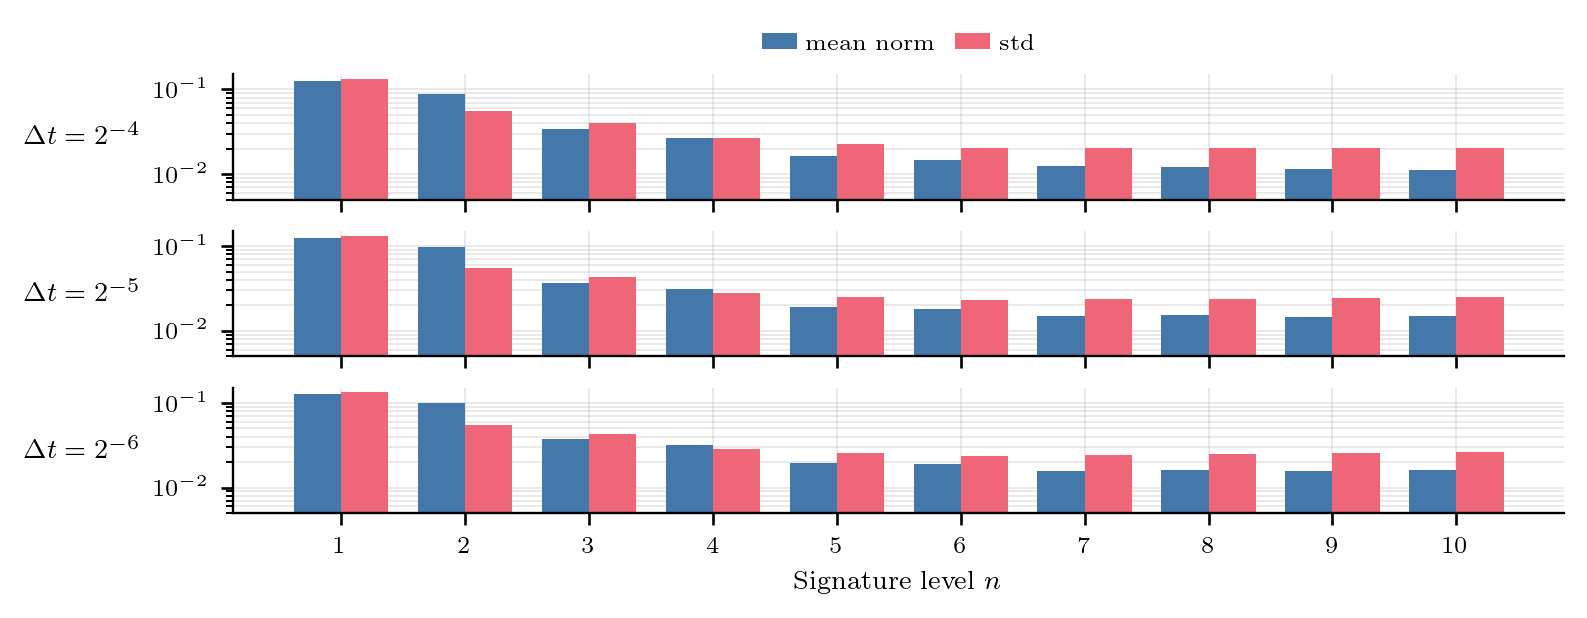

In [4]:
import sys
sys.path.insert(0, 'validation')
import plot_config  # applies rcParams
from plot_config import FULL_WIDTH, COLORS, savefig_fig
import matplotlib.pyplot as plt
from pathlib import Path

dt_values = df["dt"].drop_duplicates().to_list()[1:]  # skip coarsest
n_dt = len(dt_values)

ROW_HEIGHT = 0.82  # inches per row
fig, axes = plt.subplots(n_dt, 1, figsize=(FULL_WIDTH, ROW_HEIGHT * n_dt), sharex=True)

if n_dt == 1:
    axes = [axes]

bar_width = 0.38

for ax, dt in zip(axes, dt_values):
    g = df[df["dt"] == dt]
    x = g["level"].to_numpy()
    ax.bar(x - bar_width / 2, g["mean_norm"], width=bar_width, color=COLORS[0], label="mean norm")
    ax.bar(x + bar_width / 2, g["std"],       width=bar_width, color=COLORS[1], label="std")
    ax.set_yscale("log")
    ax.set_ylabel(rf"$\Delta t = {dt.strip('$')}$", rotation=0, ha="right", va="center")
    ax.grid(True, axis="y", which="both")
    ax.set_ylim(0.5e-2, 1.5e-1)

axes[-1].set_xlabel(r"Signature level $n$")
axes[-1].set_xticks(range(1, trunc + 1))
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.5), ncol=2, frameon=False)

out_path = Path('validation') / OUTPUT_DIR
out_path.mkdir(parents=True, exist_ok=True)
savefig_fig(fig, out_path / "signature_level_stats_by_dt", ["pdf", "png"])
plt.show()

## 1. Λ = 0 correctness check

When $\Lambda = 0$ the matrix exponential $e^{\Lambda \Delta t} = I$ for all $\Delta t$, and the
state-space recursion collapses to a plain iterated integral.  Concretely, with $Y_t = A X_t \in \mathbb{R}^m$,

$$
\mathrm{SSS}_{\Lambda=0}(X)^n \;=\; \mathrm{Sig}(Y)^n, \qquad n = 1, \ldots, N.
$$

We verify this to **float64 precision** (max absolute error $< 10^{-12}$) for several
$(q, R, m, d)$ configurations.

In [5]:
%run validation/validate_lambda0.py

 q  R  m  d  N      max_abs   max_scaled     mean_abs  mean_scaled
 1  1  2  2  1 2.775558e-17 2.775558e-17 1.301043e-17 1.301043e-17
 1  1  2  2  2 3.122502e-16 6.245005e-16 1.124758e-16 2.249516e-16
 1  1  2  2  3 3.122502e-16 6.245005e-16 1.124758e-16 2.249516e-16
 1  1  2  2  4 3.122502e-16 6.245005e-16 1.124758e-16 2.249516e-16
 1  1  2  2  5 3.122502e-16 6.245005e-16 1.124758e-16 2.249516e-16
 1  1  2  2  6 3.122502e-16 6.245005e-16 1.124758e-16 2.249516e-16
 1  1  2  2  7 3.122502e-16 6.245005e-16 1.124758e-16 2.249516e-16
 1  1  2  2  8 3.122502e-16 6.245005e-16 1.124758e-16 2.249516e-16
 1  1  2  2  9 3.122502e-16 6.245005e-16 1.124758e-16 2.249516e-16
 1  1  2  2 10 3.122502e-16 6.245005e-16 1.124758e-16 2.249516e-16
 3  2  2  2  1 8.500145e-17 8.500145e-17 3.480289e-17 3.480289e-17
 3  2  2  2  2 1.172673e-15 2.345346e-15 3.111050e-16 6.222101e-16
 3  2  2  2  3 1.172673e-15 2.345346e-15 3.111050e-16 6.222101e-16
 3  2  2  2  4 1.172673e-15 2.345346e-15 3.111050e-16 6.222101

## 2. Euler convergence

The exact FSSK is evaluated via a **matrix-exponential recursion** along the path grid.
An alternative is the **Euler scheme**: replace $e^{\Lambda \Delta t} \approx I + \Lambda \Delta t$
at each step.  This is first-order accurate, so refining the grid by a factor of 2 (one dyadic
level) should halve the error:

$$
\bigl\|\mathrm{SSS}_{\mathrm{Euler},k}(X) - \mathrm{SSS}_{\mathrm{exact}}(X)\bigr\|
\;=\; O(2^{-k}), \qquad k = 0, 1, 2, \ldots
$$

We fix the coarse grid ($J$ points, $d$-dimensional paths) and sweep dyadic refinement orders
$k = 0, \ldots, k_{\max}$.  For each setup $(q, R)$ and each signature level $n$ we plot

$$
n! \cdot \max_{\text{paths},\,\text{entries}} \bigl|S^n_{\mathrm{exact}} - S^n_{\mathrm{Euler},k}\bigr|
$$

against $k$ on a log scale.  A slope of $-1$ confirms first-order convergence.

In [6]:
# -- Parameters (edit here) --
J          = 16    # coarse path grid points (J-1 increments)
N          = 7     # signature truncation level
m          = 3     # latent-path dimension
d          = 3     # input-path dimension
n_paths    = 128   # batch size
max_dyadic = 8     # sweep dyadic orders 0 ... max_dyadic
path_seed  = 20226 # RNG seed for path generation
setups = [
    {"q": 1, "R": 1, "seed": 412},
    {"q": 2, "R": 2, "seed": 431},
    {"q": 4, "R": 3, "seed": 144},
]

In [11]:
import subprocess, sys, json
from pathlib import Path
from IPython.display import display, Image
import pandas as pd

script = Path('validation/validate_euler_convergence_demo.py').resolve()
result = subprocess.run(
    [
        sys.executable, str(script),
        '--J',          str(J),
        '--N',          str(N),
        '--m',          str(m),
        '--d',          str(d),
        '--n-paths',    str(n_paths),
        '--max-dyadic', str(max_dyadic),
        '--path-seed',  str(path_seed),
        '--setups',     json.dumps(setups),
        '--output-dir', str(Path('validation') / OUTPUT_DIR),
    ],
    cwd=str(script.parent.parent),
    capture_output=False,
)
if result.returncode != 0:
    raise RuntimeError(
        f'validate_euler_convergence_demo.py failed with exit code {result.returncode}'
    )


── q=1, R=1 ──────────────────────────────
  dyadic=0  lvl1=3.64e-03  lvl2=1.33e-02  lvl3=5.74e-03  lvl4=3.13e-03  lvl5=1.20e-03  lvl6=6.15e-04  lvl7=3.59e-04
  dyadic=1  lvl1=1.80e-03  lvl2=6.44e-03  lvl3=2.85e-03  lvl4=1.60e-03  lvl5=6.94e-04  lvl6=3.19e-04  lvl7=1.98e-04
  dyadic=2  lvl1=8.93e-04  lvl2=3.18e-03  lvl3=1.42e-03  lvl4=8.05e-04  lvl5=3.71e-04  lvl6=1.61e-04  lvl7=1.03e-04
  dyadic=3  lvl1=4.45e-04  lvl2=1.58e-03  lvl3=7.10e-04  lvl4=4.04e-04  lvl5=1.91e-04  lvl6=8.41e-05  lvl7=5.22e-05
  dyadic=4  lvl1=2.22e-04  lvl2=7.86e-04  lvl3=3.55e-04  lvl4=2.02e-04  lvl5=9.71e-05  lvl6=4.34e-05  lvl7=2.63e-05
  dyadic=5  lvl1=1.11e-04  lvl2=3.92e-04  lvl3=1.77e-04  lvl4=1.01e-04  lvl5=4.89e-05  lvl6=2.20e-05  lvl7=1.33e-05
  dyadic=6  lvl1=5.54e-05  lvl2=1.96e-04  lvl3=8.86e-05  lvl4=5.07e-05  lvl5=2.46e-05  lvl6=1.11e-05  lvl7=6.67e-06
  dyadic=7  lvl1=2.77e-05  lvl2=9.79e-05  lvl3=4.43e-05  lvl4=2.53e-05  lvl5=1.23e-05  lvl6=5.57e-06  lvl7=3.35e-06
  dyadic=8  lvl1=1.39e-05  l

-- Convergence rates (fitted log2 slope per setup x level) --


,label,q,R,level,slope,intercept_log2
0,"q=1, R=1",1,1,1,-1.003897,-8.115099
1,"q=1, R=1",1,1,2,-1.008130,-6.267799
2,"q=1, R=1",1,1,3,-1.001911,-7.450415
3,"q=1, R=1",1,1,4,-0.994932,-8.298608
4,"q=1, R=1",1,1,5,-0.961275,-9.546845
5,"q=1, R=1",1,1,6,-0.971964,-10.639098
6,"q=1, R=1",1,1,7,-0.975061,-11.345061
7,"q=2, R=2",2,2,1,-1.003489,-9.871726
8,"q=2, R=2",2,2,2,-1.002310,-6.202416
9,"q=2, R=2",2,2,3,-0.994727,-7.064573



-- Scaled max errors  n! * max|S^n_exact - S^n_Euler| --


label         q=1, R=1                                                    \
level                1         2         3         4         5         6   
dyadic_order                                                               
0             0.003644  0.013259  0.005744  0.003128  0.001200  0.000615   
1             0.001797  0.006443  0.002855  0.001597  0.000694  0.000319   
2             0.000893  0.003177  0.001423  0.000805  0.000371  0.000161   
3             0.000445  0.001577  0.000710  0.000404  0.000191  0.000084   
4             0.000222  0.000786  0.000355  0.000202  0.000097  0.000043   
5             0.000111  0.000392  0.000177  0.000101  0.000049  0.000022   
6             0.000055  0.000196  0.000089  0.000051  0.000025  0.000011   
7             0.000028  0.000098  0.000044  0.000025  0.000012  0.000006   
8             0.000014  0.000049  0.000022  0.000013  0.000006  0.000003   

label                   q=2, R=2                      ...                      \
level                7         1         2         3  ...         5         6   
dyadic_order                                          ...                       
0             0.000359  0.001077  0.013663  0.007367  ...  0.000969  0.000638   
1             0.000198  0.000532  0.006776  0.003753  ...  0.000579  0.000326   
2             0.000103  0.000264  0.003375  0.001893  ...  0.000313  0.000165   
3             0.000052  0.000132  0.001684  0.000951  ...  0.000162  0.000083   
4             0.000026  0.000066  0.000841  0.000477  ...  0.000083  0.000042   
5             0.000013  0.000033  0.000420  0.000239  ...  0.000042  0.000021   
6             0.000007  0.000016  0.000210  0.000119  ...  0.000021  0.000011   
7             0.000003  0.000008  0.000105  0.000060  ...  0.000011  0.000005   
8             0.000002  0.000004  0.000053  0.000030  ...  0.000005  0.000003   

label                   q=4, R=3                                          \
level                7         1         2         3         4         5   
dyadic_order                                                               
0             0.000492  0.001722  0.012288  0.004079  0.002106  0.000716   
1             0.000275  0.000856  0.006057  0.002059  0.001124  0.000427   
2             0.000145  0.000427  0.003007  0.001034  0.000580  0.000232   
3             0.000074  0.000213  0.001498  0.000518  0.000294  0.000121   
4             0.000038  0.000106  0.000748  0.000259  0.000148  0.000062   
5             0.000019  0.000053  0.000374  0.000130  0.000074  0.000031   
6             0.000009  0.000027  0.000187  0.000065  0.000037  0.000016   
7             0.000005  0.000013  0.000093  0.000032  0.000019  0.000008   
8             0.000002  0.000007  0.000047  0.000016  0.000009  0.000004   

label                             
level                6         7  
dyadic_order                      
0             0.000376  0.000223  
1             0.000205  0.000120  
2             0.000106  0.000064  
3             0.000054  0.000033  
4             0.000027  0.000017  
5             0.000014  0.000008  
6             0.000007  0.000004  
7             0.000003  0.000002  
8             0.000002  0.000001  

[9 rows x 21 columns]

euler_conv_demo_q_1_R_1


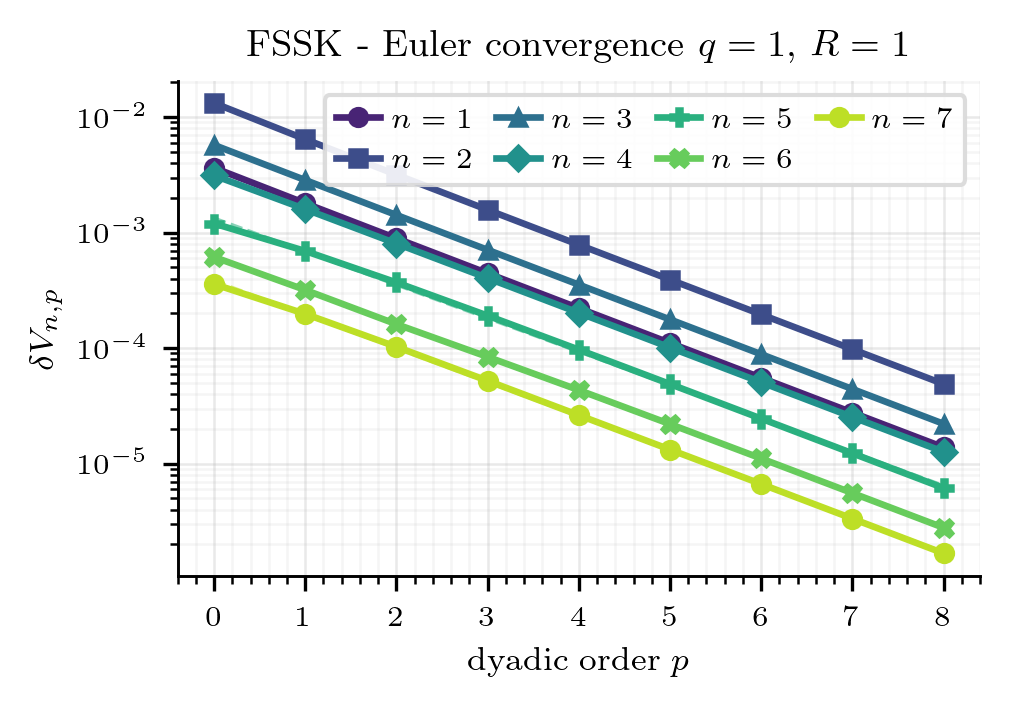

euler_conv_demo_q_2_R_2


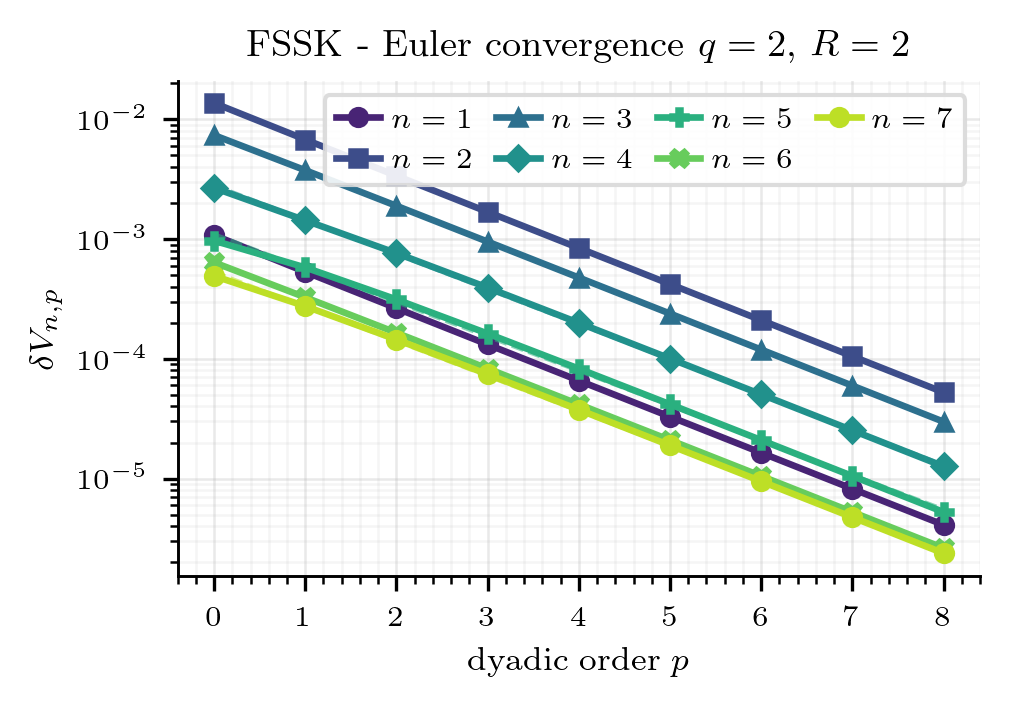

euler_conv_demo_q_4_R_3


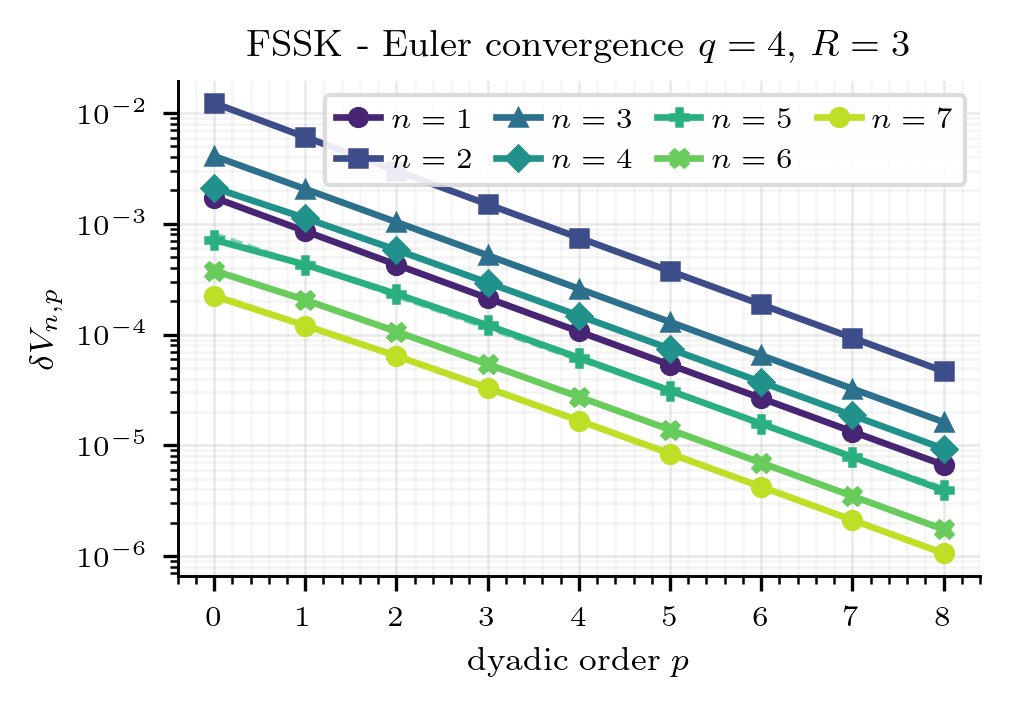

In [12]:
from pathlib import Path
from IPython.display import display, Image
import pandas as pd

out = Path('validation') / OUTPUT_DIR

print('-- Convergence rates (fitted log2 slope per setup x level) --')
display(pd.read_csv(out / 'euler_conv_demo_rates.csv'))

print('\n-- Scaled max errors  n! * max|S^n_exact - S^n_Euler| --')
df_err = pd.read_csv(out / 'euler_conv_demo_errors.csv')
display(df_err.pivot_table(index='dyadic_order', columns=['label', 'level'],
                           values='scaled_max_error'))

for png in sorted(out.glob('euler_conv_demo_*.png')):
    print(png.stem)
    display(Image(filename=str(png)))

## 3. FLOP scaling

The dominant cost of the exact FSSK recursion is the shuffle-product accumulation over
multi-indices.  The predicted work per kernel evaluation is

$$
W_q \;=\; (J-1)\,R^2\,
\begin{cases}
m^N & q = 1, \\
N\,m^N & q > 1.
\end{cases}
$$

We sweep over $(J, N, m, R, q)$ configurations, record the **XLA FLOP count** via
`jax.xla_computation`, and verify that $\mathrm{FLOPs} \propto W_q$ on log-log axes.

In [8]:
RUN_REGIME = "MEDIUM"   # SMALL | MEDIUM | LARGE

Loaded rows     : 1200
Valid FLOP rows : 1200
q values        : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
J values        : [np.int64(32), np.int64(33), np.int64(34), np.int64(36), np.int64(37), np.int64(41), np.int64(44), np.int64(53), np.int64(54), np.int64(59), np.int64(62), np.int64(63), np.int64(66), np.int64(67), np.int64(68), np.int64(70), np.int64(71), np.int64(76), np.int64(80), np.int64(82), np.int64(84), np.int64(86), np.int64(88), np.int64(91), np.int64(94), np.int64(95), np.int64(97), np.int64(100), np.int64(102), np.int64(104), np.int64(105), np.int64(106), np.int64(113), np.int64(115), np.int64(118), np.int64(119), np.int64(120), np.int64(121), np.int64(127), np.int64(132), np.int64(138), np.int64(140), np.int64(143), np.int64(144), np.int64(146), np.int64(147), np.int64(148), np.int64(151), np.int64(153), np.int64(157), np.int64(167), np.int64(169), np.int64(173), np.int64(175), np.int64(178), np.int64(189), np.int64(191), np.int64(194), np.int64(195), np.int

,q,n_points,W_min,W_max,flops_min,flops_max,pearson_log,spearman_log
0,1,300,492075.0,8.150337e+08,8040222.0,2.231371e+10,0.998223,0.997874
1,2,300,2460375.0,8.207575e+09,22832361.0,9.364167e+10,0.999464,0.999350
2,3,300,2460375.0,8.207575e+09,44729901.0,2.630972e+11,0.998327,0.998168
3,4,300,2460375.0,8.207575e+09,83628531.0,7.528155e+11,0.996391,0.996471


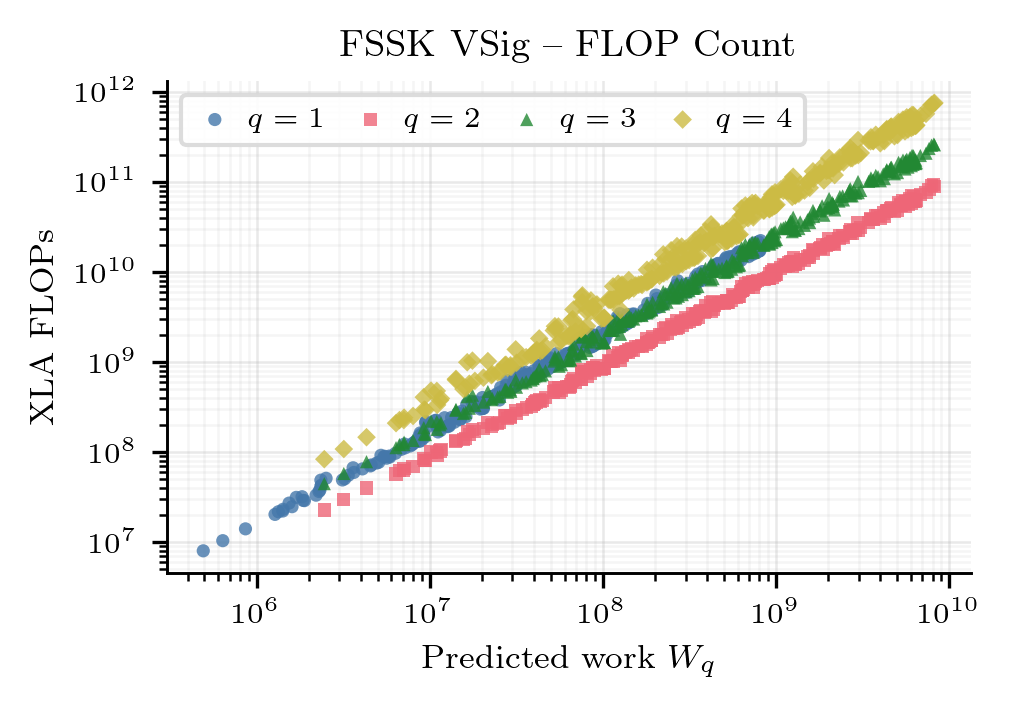

In [10]:
import subprocess, sys
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

tag = RUN_REGIME.lower()

script = Path('validation/analyse_flop_scaling.py').resolve()
result = subprocess.run(
    [sys.executable, str(script), '--regime', RUN_REGIME],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f'analyse_flop_scaling.py failed with exit code {result.returncode}')

out_dir = Path('validation/validation_outputs')

print('FLOP scaling summary (Spearman / Pearson log-correlation per q)')
display(pd.read_csv(out_dir / f'fssk_flop_scaling_{tag}_summary.csv'))

display(Image(filename=str(out_dir / f'fssk_flop_scaling_{tag}_xla_flops_vs_predicted_work.png')))

## 4. Wall-clock and CPU time vs. predicted work $W_q$

The theoretical cost model predicts that the hot-path runtime should scale as

$$
T_{\mathrm{hot}} \;\approx\; C_q \cdot W_q(J, R; N),
\qquad
W_q =
(J-1)\,R^2
\begin{cases}
m^N & q = 1,\\
N\,m^N & q > 1.
\end{cases}
$$

We verify this empirically by sweeping $(J, N, R, q, m)$ with the regime sampler,
timing the hot FSSK evaluation with `time.perf_counter` (wall) and
`time.process_time_ns` (CPU), and plotting both against $W_q$ on log-log axes.
A slope of $1$ on the log-log scale confirms the linear scaling prediction.

In [4]:
# -- Parameters (edit here) --
RUN_REGIME_TIMING = "MEDIUM"   # SMALL | MEDIUM | LARGE
TIMING_REPEATS    = None        # None = use regime default; or e.g. 5

Loaded 1200 rows from validation/validation_outputs/fssk_exact_scaling_timings_medium.pkl
q distribution:


,count
q,
1,300
2,300
3,300
4,300


  Saved: validation/validation_outputs/fssk_wall_vs_work_medium.pdf
  Saved: validation/validation_outputs/fssk_wall_vs_work_medium.png


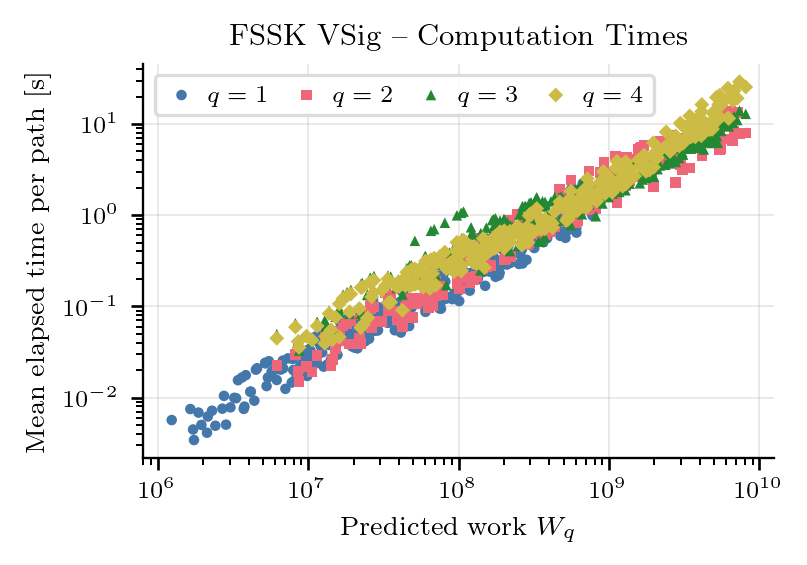

In [12]:
import sys
sys.path.insert(0, 'validation')
import plot_config
from plot_config import HALF_WIDTH, COLORS, MARKERS, SCATTER_SIZE, savefig_fig
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display
from scipy.stats import spearmanr, pearsonr

tag     = RUN_REGIME_TIMING.lower()
out_dir = Path('validation/validation_outputs')
pkl     = out_dir / f'fssk_exact_scaling_timings_{tag}.pkl'

df = pd.read_pickle(pkl)
for col in ['q', 'J', 'R', 'N', 'm', 'wall_hot_median_s', 'cpu_hot_median_s']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['q', 'J', 'R', 'N', 'm', 'wall_hot_median_s']).copy()

df['W_q'] = np.where(
    df['q'] == 1,
    (df['J'] - 1) * df['R']**2 * df['m']**df['N'],
    (df['J'] - 1) * df['R']**2 * df['N'] * df['m']**df['N'],
)

print(f'Loaded {len(df)} rows from {pkl}')
print('q distribution:')
display(df['q'].value_counts().sort_index().rename('count').to_frame())

qs = sorted(df['q'].unique())

sub = df.dropna(subset=['cpu_hot_mean_s'])
fig, ax = plt.subplots(figsize=(HALF_WIDTH, HALF_WIDTH / 1.45))
for i, q in enumerate(qs):
    g = sub[sub['q'] == q]
    ax.scatter(
        g['W_q'], g['wall_hot_mean_s'],
        color=COLORS[i % len(COLORS)],
        marker=MARKERS[i % len(MARKERS)],
        s=SCATTER_SIZE, edgecolors='none', label=f'$q={q}$',
    )
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'Predicted work $W_q$')
ax.set_ylabel(r'Mean elapsed time per path [s]')
ax.set_title(r'FSSK $\mathrm{VSig}$ -- Computation Times')
ax.legend(ncol=len(qs), loc='upper left', frameon=True)
savefig_fig(fig, out_dir / f'fssk_wall_vs_work_{tag}', ['pdf', 'png'])
plt.show()

In [24]:
x = sub["wall_hot_mean_s"]/sub["cpu_hot_mean_s"]
x.median(), x.min(), x.max()

(np.float64(0.37167845971055363),
 np.float64(0.17282664321430824),
 np.float64(0.9926702383402887))